Data preprocessing:

In [13]:
import pandas as pd
df_raw = pd.read_csv('/content/mpc_acc_v24.csv')
df_ml = pd.DataFrame()
df_ml['distance_error_cm'] = df_raw['df'] * 100
df_ml['velocity_error_cmps'] = (df_raw['v_ref'] - df_raw['speed']) * 100
df_ml['actual_velocity_cmps'] = df_raw['speed'] * 100
df_ml['leader_velocity_cmps'] = df_raw['v_leader'] * 100
df_ml['prev_pwm_output'] = df_raw['pwm'].shift(1).fillna(0)
df_ml['pwm_output'] = df_raw['pwm']
df_ml = df_ml.dropna().iloc[1:].reset_index(drop=True)
features = [
    'distance_error_cm',
    'velocity_error_cmps',
    'actual_velocity_cmps',
    'leader_velocity_cmps',
    'prev_pwm_output'
]

X = df_ml[features]
y = df_ml['pwm_output']
df_ml.to_csv('dataset.csv', index=False)


libraries:

In [14]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Collected MPC data:

In [15]:
df = pd.read_csv('dataset.csv')

Defining Features (X) and Target (y):

In [16]:
features = [
    'distance_error_cm',
    'velocity_error_cmps',
    'actual_velocity_cmps',
    'leader_velocity_cmps',
    'prev_pwm_output'
]
X = df[features]
y = df['pwm_output']

Spliting into training and testing sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling the data:

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the Model:

In [19]:
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=3000,
    random_state=42
)

In [20]:
print("Training model...")
model.fit(X_train_scaled, y_train)
print(f"Training complete! Iterations reached: {model.n_iter_}")

Training model...
Training complete! Iterations reached: 372


Evaluating the Model:

In [21]:
# 1. Import the necessary metric functions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error
import numpy as np
y_pred = model.predict(X_test_scaled)

# 3. Calculate the metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 4. Print the exact terms you requested
print("\n--- Accuracy Metrics ---")
print(f"MSE:          {mse:.5f}")
print(f"RMSE:         {rmse:.5f} (Average magnitude of error spikes)")
print(f"MAE:          {mae:.5f} (Average everyday deviation)")
print(f"Max Error:    {max_err:.5f} (Worst-case deviation)")
print(f"R-squared:    {r2:.5f} (1.0 is a perfect clone of the expert)")


--- Accuracy Metrics ---
MSE:          51.89488
RMSE:         7.20381 (Average magnitude of error spikes)
MAE:          1.60061 (Average everyday deviation)
Max Error:    86.70938 (Worst-case deviation)
R-squared:    0.98873 (1.0 is a perfect clone of the expert)


In [22]:
import time
import numpy as np

print("--- Robotics & Hardware Metrics ---")

# 1. Measure Inference Speed (Latency)
# We test how long it takes to predict ONE sample (since the robot does one at a time)
single_sample = X_test_scaled[0].reshape(1, -1)

# Run a quick warmup (sometimes the first prediction is artificially slow)
_ = model.predict(single_sample)

# Time 1000 single predictions to get a reliable average
start_time = time.time()
for _ in range(1000):
    _ = model.predict(single_sample)
end_time = time.time()

avg_inference_time_ms = ((end_time - start_time) / 1000) * 1000
print(f"Average Inference Time: {avg_inference_time_ms:.4f} milliseconds")
if avg_inference_time_ms < 150: # 150ms is your 0.15s sample interval
    print("  -> STATUS: PASS (Model is fast enough for the 0.15s control loop)")
else:
    print("  -> STATUS: FAIL (Model is too slow!)")


# 2. Measure Smoothness (Jitter)
# We calculate the step-to-step changes (derivatives) in the PWM
pid_changes = np.abs(np.diff(y_test))
ai_changes = np.abs(np.diff(y_pred))

avg_pid_step = np.mean(pid_changes)
avg_ai_step = np.mean(ai_changes)

print(f"\nAverage PWM jump per step (PID): {avg_pid_step:.2f} PWM units")
print(f"Average PWM jump per step (AI):  {avg_ai_step:.2f} PWM units")

if avg_ai_step > avg_pid_step * 1.5:
    print("  -> WARNING: The AI model is significantly more 'jittery' than the PID. This could cause motor wear.")
else:
    print("  -> STATUS: PASS (AI outputs are smoothly transitioning)")

--- Robotics & Hardware Metrics ---
Average Inference Time: 0.3983 milliseconds
  -> STATUS: PASS (Model is fast enough for the 0.15s control loop)

Average PWM jump per step (PID): 69.32 PWM units
Average PWM jump per step (AI):  68.73 PWM units
  -> STATUS: PASS (AI outputs are smoothly transitioning)


In [23]:
W1, W2, W3 = model.coefs_
b1, b2, b3 = model.intercepts_

np.savez("mpc_mlp_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
np.savez("mpc_mlp_scaler.npz", mean=scaler.mean_, scale=scaler.scale_)
print("Saved mpc_mlp_weights.npz and mpc_mlp_scaler.npz for the Raspberry Pi!")

Saved mpc_mlp_weights.npz and mpc_mlp_scaler.npz for the Raspberry Pi!


results:

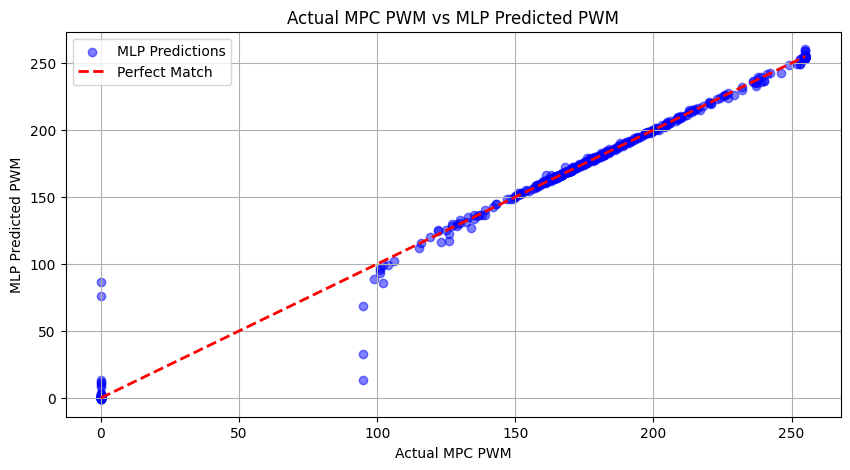

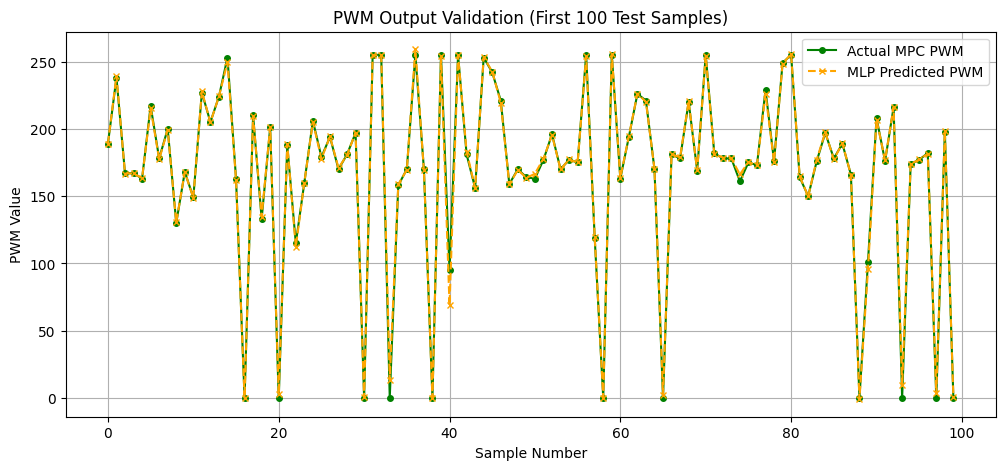

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='MLP Predictions')
plt.plot([0, 255], [0, 255], color='red', linestyle='--', linewidth=2, label='Perfect Match')
plt.title('Actual MPC PWM vs MLP Predicted PWM')
plt.xlabel('Actual MPC PWM')
plt.ylabel('MLP Predicted PWM')
plt.legend()
plt.grid(True)
plt.show()

y_test_list = y_test.values.tolist()

plt.figure(figsize=(12, 5))
plt.plot(y_test_list[:100], label='Actual MPC PWM', color='green', marker='o', markersize=4)
plt.plot(y_pred[:100], label='MLP Predicted PWM', color='orange', linestyle='--', marker='x', markersize=4)
plt.title('PWM Output Validation (First 100 Test Samples)')
plt.xlabel('Sample Number')
plt.ylabel('PWM Value')
plt.legend()
plt.grid(True)
plt.show()